In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


--- MULTI-ASSET RISK & ESG PROFILE ---


,Asset,Expected Return,Volatility,Duration (Yrs),Carbon Density (tCO2e/$M)
0,Adani Green (Pure Green),0.130,0.28,6.2,12
1,NHPC (Pure Green),0.105,0.22,5.8,5
2,Tata Power (Transition),0.120,0.25,5.5,450
3,NTPC (Transition),0.110,0.23,5.1,680
4,Power Grid (Grid/Conventional),0.090,0.16,4.8,80
5,Coal India (Grey),0.085,0.24,4.2,1250
6,10Y Sovereign G-Sec,0.071,0.06,7.5,0
7,30Y Sovereign Green Bond,0.074,0.09,18.2,0


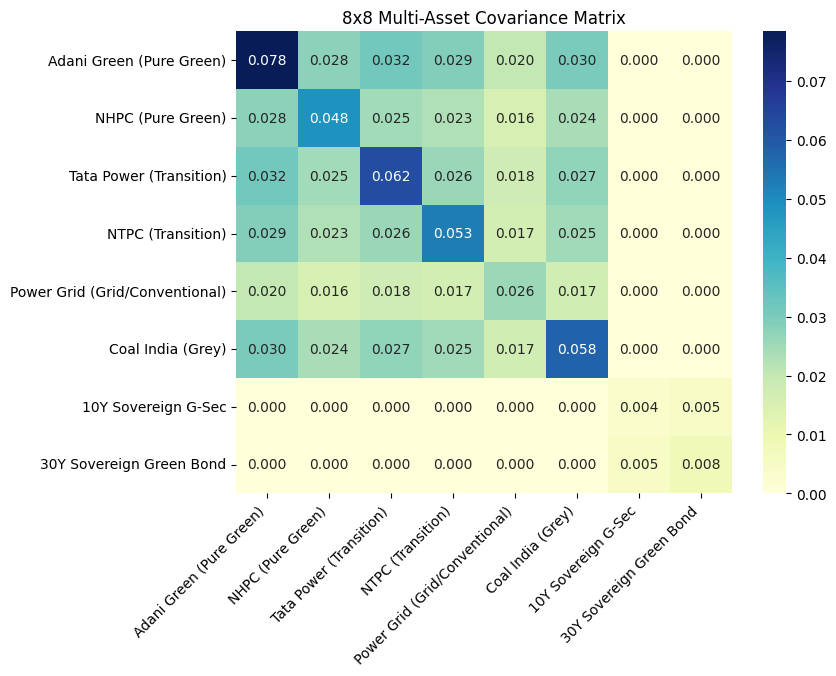

In [2]:
assets = [
    'Adani Green (Pure Green)',
    'NHPC (Pure Green)',
    'Tata Power (Transition)',
    'NTPC (Transition)',
    'Power Grid (Grid/Conventional)',
    'Coal India (Grey)',
    '10Y Sovereign G-Sec',
    '30Y Sovereign Green Bond'
]

# Expected Returns & Carbon Intensities (tCO2e / $M Revenue)
expected_returns = np.array([0.130, 0.105, 0.120, 0.110, 0.090, 0.085, 0.071, 0.074])
carbon_intensity = np.array([12, 5, 450, 680, 80, 1250, 0, 0])
durations = np.array([6.2, 5.8, 5.5, 5.1, 4.8, 4.2, 7.5, 18.2])

# Construct Representative Multi-Asset Covariance Matrix (8x8)
np.random.seed(42)
volatilities = np.array([0.28, 0.22, 0.25, 0.23, 0.16, 0.24, 0.06, 0.09])
corr_matrix = np.eye(8)

# Fill correlation estimates (higher between same asset classes)
for i in range(6):
    for j in range(6):
        if i != j: corr_matrix[i, j] = 0.45
corr_matrix[6, 7] = corr_matrix[7, 6] = 0.85 # Strong bond correlation

cov_matrix = np.outer(volatilities, volatilities) * corr_matrix

# Print Summary Table
df_assets = pd.DataFrame({
    'Asset': assets,
    'Expected Return': expected_returns,
    'Volatility': volatilities,
    'Duration (Yrs)': durations,
    'Carbon Density (tCO2e/$M)': carbon_intensity
})
print("--- MULTI-ASSET RISK & ESG PROFILE ---")
display(df_assets)

plt.figure(figsize=(8, 6))
sns.heatmap(cov_matrix, xticklabels=assets, yticklabels=assets, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("8x8 Multi-Asset Covariance Matrix")
plt.xticks(rotation=45, ha='right')
plt.show()